# Preparing iNaturalist2017 Training and Validation Set

Notes:
- `prep_sets.py` just runs some preprocessing on the JSON files for easier access to image filenames and labels.
- There is class imbalance in the dataset, distribution of images per category follows the observation frequency of that category. Consider techniques (oversampling, smote, etc) to manage classes with few examples following analysis of confusion matrix.
- On the resizing strategy, padding minimizes subject loss and maintains aspect ratio. Distortion via resizing or potentially cropping out important features is more risky for ViTs than padding. Attention mechanisms can learn to ignore padding regions (even without configuring any attention masks). We can inspect our attention maps to ensure these areas receive low attention scores. Hopefully the ViT can use the positional embeddings (and an understanding of the spatial arrangement of the patches) to differentiate padded regions from patches with actual content.

Plan for data preprocessing (repeat the following for both training and validation sets):
- Load and process JSON files into just filename and category ids, then shuffle on disk.
- Load processed JSON files and batch the annotations, attaching the labels. For each annotation batch, construct a dataset, load the images, resize and normalize them, and finally shuffle the batch.
- Serialize batch of images to single TFRecord file, repeat for all batches in the given set.
- Shuffle on disk.

Then the processed datasets can be uploaded to S3 for training in SaturnCloud. Data augmentation can be applied above too, different strategies can be used for cropping (even using bounding boxes where present), though padding seems most sensible and straightforward given the model architecture.

Plan for data ingestion pipeline:

- Create data ingestion pipeline, to read in and train from TFRecord files (for specific load size + parallel reading and prefetching), pause training, reload next chunk from S3, repeat (don't want to load all data onto disk in SaturnCloud). In pipeline include interleaving (see book), shuffling, batching and prefetching configurations.

In [35]:
# funcs
def batch_annotations(annotations, batch_size):
    batches = []
    for i in range(0, len(annotations), batch_size):
        batch = annotations[i:i+batch_size]
        file_names, labels = [], []
        for example in batch:
            file_names.append(example["file_name"])
            labels.append(example["category_id"])
        batches.append((file_names, labels))
    return batches

def preprocess_image(file_name, label, resize_method="pad"):
    # load and decode jpeg
    file_name = "./train_val_images/Aves/Piranga bidentata/3bd614b3011fd77571d44f0a41fae950.jpg"
    image = tf.io.read_file(file_name)
    image = tf.io.decode_jpeg(image, channels=3)

    # resize
    if resize_method == "crop_or_pad":
        image = tf.image.resize_with_crop_or_pad(image, 244, 244)
    elif resize_method == "pad":
        image = tf.image.resize_with_pad(image, 244, 244)
    else:
        image = tf.image.resize(image, [244, 244])
    
    # normalize pixel values
    image = image / 127.5 - 1.0 # resize output already float32 - now ranged [-1, 1]

    # inspect value in graph mode (alternatively can turn on eager mode for debugging)
    # tf.print("Range", tf.reduce_min(image), "Max value:", tf.reduce_max(image))

    return image, label

def _int64_feature(value):
    return tf.train.Feature(int64_list=tf.train.Int64List(value=[value]))

def _float_feature(value):
    return tf.train.Feature(float_list=tf.train.FloatList(value=value))

def serialize_example(image, label):
    image_shape = image.shape

    feature = {
        "height": _int64_feature(image_shape[0]),
        "width": _int64_feature(image_shape[1]),
        "depth": _int64_feature(image_shape[2]),
        "label": _int64_feature(label.numpy()),
        "image": _float_feature(image.numpy().flatten())
    }
    
    return tf.train.Example(features=tf.train.Features(feature=feature)).SerializeToString()

def write_tfrecord(dataset, record_file):
    with tf.io.TFRecordWriter(record_file) as writer:
        for image, label in dataset:
            serialized_example = serialize_example(image, label)
            writer.write(serialized_example)

def display_first_n_batch_images(dataset, n):
    plt.figure(figsize=(10, 5))
    for i, (image, label) in enumerate(dataset.take(n)):
        plt.subplot(1, n, i+1)
        plt.imshow((image + 1) / 2) # or plt.imshow(tf.cast((image + 1) * 127.5, tf.uint8))
        plt.title(label.numpy()) # category id
        plt.axis('off')
    plt.show()

(['train_val_images/Mammalia/Marmota flaviventris/3c919dfdcfe7837b420d3dc640c21c70.jpg', 'train_val_images/Mammalia/Marmota flaviventris/14bcd8bf7a49b3a26ed9c73986bdc828.jpg'], [0, 0]) 

Write tfrecord complete for train_val_images-processed/val2017/inat17_batch-1-of-6 



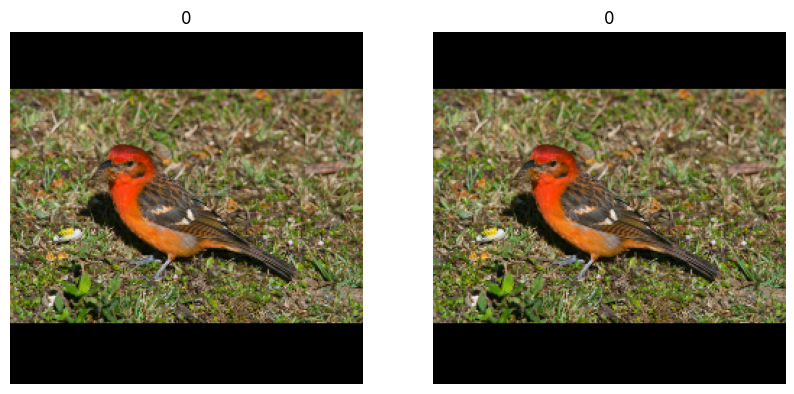

(['train_val_images/Mammalia/Marmota flaviventris/488272f1fec42b2029f3dd78780a57f8.jpg', 'train_val_images/Mammalia/Marmota flaviventris/b2692ce861115c0405b162181cfe578a.jpg'], [0, 0]) 

Write tfrecord complete for train_val_images-processed/val2017/inat17_batch-2-of-6 



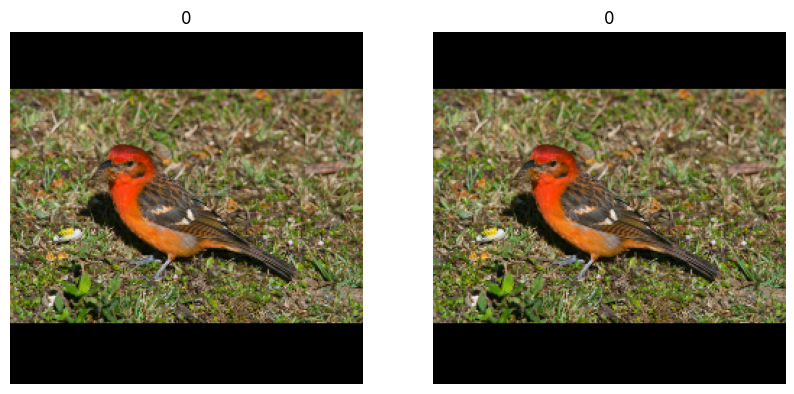

(['train_val_images/Mammalia/Marmota flaviventris/34e4892a2cb23d54c2c90256ceeee413.jpg', 'train_val_images/Mammalia/Marmota flaviventris/e7b8bc321665d110f4e0d04eb254cbe7.jpg'], [0, 0]) 

Write tfrecord complete for train_val_images-processed/val2017/inat17_batch-3-of-6 



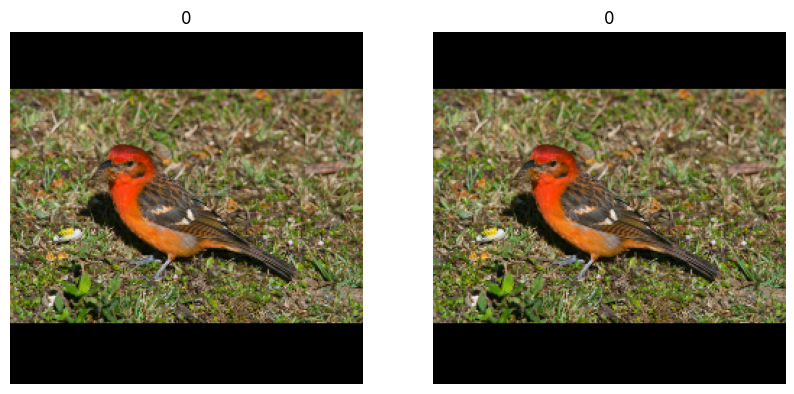

(['train_val_images/Mammalia/Marmota flaviventris/0b172c792f0c6975906c3cb9f6ec4b5f.jpg', 'train_val_images/Mammalia/Marmota flaviventris/1909c2d50d862495d0b860d81b0e33fe.jpg'], [0, 0]) 

Write tfrecord complete for train_val_images-processed/val2017/inat17_batch-4-of-6 



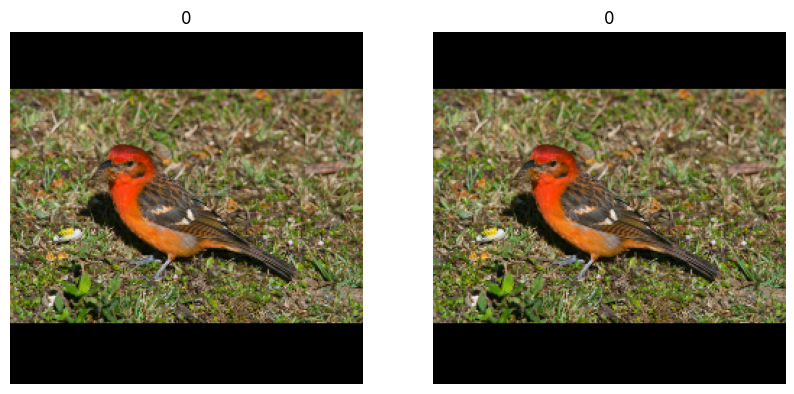

(['train_val_images/Mammalia/Marmota flaviventris/89c5d9afb4cfc22cd03e6bf20c65a2d4.jpg', 'train_val_images/Mammalia/Marmota flaviventris/5fa344663f2da2e104f3d635fc617ac8.jpg'], [0, 0]) 

Write tfrecord complete for train_val_images-processed/val2017/inat17_batch-5-of-6 



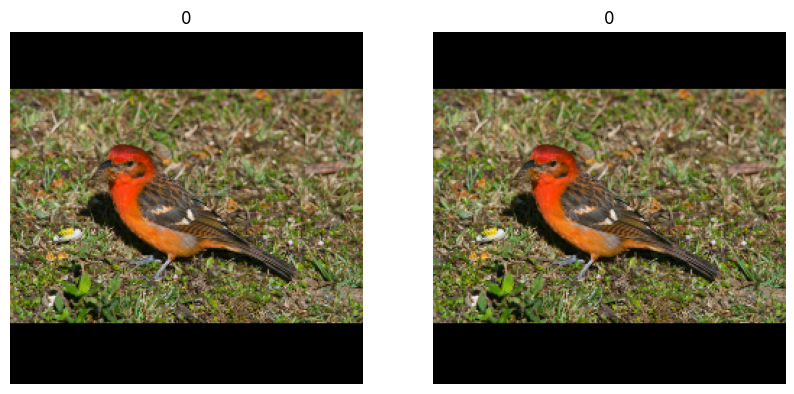

(['train_val_images/Mammalia/Marmota flaviventris/61352c412a46400bfce880e904b4f612.jpg'], [0]) 

Write tfrecord complete for train_val_images-processed/val2017/inat17_batch-6-of-6 



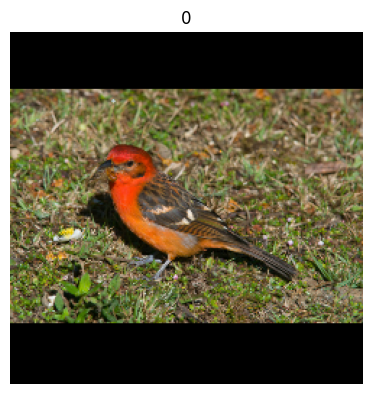

In [36]:
import tensorflow as tf
import matplotlib.pyplot as plt
import json
import os

# config
records_per_file = 2 # also acts as batch size / buffer size
dataset_type = "val2017"
tfrecord_file_prefix = f"train_val_images-processed/{dataset_type}/"

# read processed json batch annotations
with open(f"./train_val2017/{dataset_type}-processed.json", "r") as f:
    annotations = json.load(f)

annotations = annotations[:11]

example_batches = batch_annotations(annotations, records_per_file)
example_batches_len = len(example_batches)

# ensure tfrecord directory exists
os.makedirs(os.path.dirname(tfrecord_file_prefix), exist_ok=True)

# prepare data, preprocess and shuffle batches
for i, example_batch in enumerate(example_batches):
    print(example_batch, "\n")
    
    dataset = tf.data.Dataset.from_tensor_slices(example_batch)
    dataset = dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE).shuffle(buffer_size=records_per_file)

    tfrecord_file = f"{tfrecord_file_prefix}inat17_batch-{i+1}-of-{example_batches_len}"
    # write_tfrecord(dataset, tfrecord_file)

    # optionally display a few of the images in the batch
    display_first_n_batch_images(dataset, min(10, records_per_file))
    
    print(f"Write tfrecord complete for {tfrecord_file}", "\n")
